1. На основе учебного ноутбука проведите финальную подготовку данных. Иизмените количество сегментирующих классов с `16` на `5`.

2. Проведите суммарно не менее `10` экспериментов и визуализируйте их результаты (включая точность обучения сетей на одинаковом количестве эпох, например, на `7`):

  - изменив `filters` в сверточных слоях
  - изменив `kernel_size` в сверточных слоях
  - изменив активационную функцию в скрытых слоях с `relu` на `linear` или/и `selu`, `elu`.


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

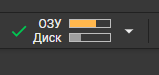



Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка

### Импорт библиотек

In [ ]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model

 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [ ]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -q 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:03<00:00, 60.6MB/s]


In [ ]:
# Глобальные параметры

IMG_WIDTH = 192               # Ширина картинки
IMG_HEIGHT = 256              # Высота картинки
NUM_CLASSES = 16              # Задаем количество классов на изображении
TRAIN_DIRECTORY = 'train'     # Название папки с файлами обучающей выборки
VAL_DIRECTORY = 'val'         # Название папки с файлами проверочной выборки

Загрузим оригинальные изображения (код из лекции):

In [ ]:
train_images = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_images = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time()  # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающей выборке
print ('Количество изображений: ', len(train_images))

cur_time = time.time() # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочной выборке
print ('Количество изображений: ', len(val_images))

Обучающая выборка загружена. Время загрузки: 0.37c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.02c
Количество изображений:  100


Загрузим сегментированные изображения (код из лекции):

In [ ]:
train_segments = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_segments = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающем наборе сегментированных изображений
print ('Количество изображений: ', len(train_segments))

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочном наборе сегментированных изображений
print ('Количество изображений: ', len(val_segments))

Обучающая выборка загружена. Время загрузки: 0.35c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.02c
Количество изображений:  100


## Решение


**Решение (v3 — экономия ОЗУ).** Ключевые меры:

* `X` хранится как `uint8` вместо `float32` (нормализация — слоем `Rescaling` внутри модели) → в 4 раза меньше памяти.
* `Y` хранится как карта классов `int8 (N, H, W)` вместо one-hot `float32 (N, H, W, 5)` → в 20 раз меньше памяти. Используется `sparse_categorical_crossentropy`.
* RGB→класс делается одной LUT по 24-битному ключу (без 16 промежуточных булевых масок).
* Обучение идёт через `tf.data.Dataset` с `prefetch` — без копирования больших тензоров.
* Между экспериментами: `del model, history` → `clear_session()` → `gc.collect()`.
* Размеры `IMG_H, IMG_W` берутся из реальной формы массива (учитывая, что в учебном `target_size=(IMG_WIDTH, IMG_HEIGHT)` keras интерпретирует как `(H, W)`).

In [ ]:
# 1. ФИНАЛЬНАЯ ПОДГОТОВКА ДАННЫХ: 16 -> 5 классов
# Ключевая оптимизация памяти:
#   * X храним как uint8 (а не float32) — в 4 раза меньше
#   * Y храним как карту классов int8 (N, H, W) — в 20 раз меньше, чем one-hot float32
#   * нормализация 1/255 будет внутри модели слоем Rescaling
#   * лоcс будет sparse_categorical_crossentropy — one-hot не нужен

import numpy as np
import gc
import tensorflow as tf

NUM_CLASSES = 5  # было 16, по заданию делаем 5

#  Цвета 16 исходных классов (RGB)
# Стандартная палитра датасета construction_256x192.
# Если ваши маски используют другие цвета — встроенный авто-детектор ниже
# найдёт фактические цвета в данных и сообщит об этом.
CLASS_COLORS_16 = [
    (0,   0,   0),    # 0  - фон
    (128, 0,   0),    # 1
    (0,   128, 0),    # 2
    (128, 128, 0),    # 3
    (0,   0,   128),  # 4
    (128, 0,   128),  # 5
    (0,   128, 128),  # 6
    (128, 128, 128),  # 7
    (64,  0,   0),    # 8
    (192, 0,   0),    # 9
    (64,  128, 0),    # 10
    (192, 128, 0),    # 11
    (64,  0,   128),  # 12
    (192, 0,   128),  # 13
    (64,  128, 128),  # 14
    (192, 128, 128),  # 15
]

#  Маппинг 16 -> 5 укрупнённых классов
# 0=фон, 1=стены, 2=проёмы, 3=крыша, 4=прочее
MAP_16_TO_5 = np.array([
    0,
    1, 1, 1,
    2, 2, 2, 2,
    3, 3, 3, 3,
    4, 4, 4, 4,
], dtype=np.int8)


def build_color_lut():
    """Хэш-таблица: RGB-цвет (24 бита) -> класс 0..15."""
    lut = np.full(256 ** 3, 255, dtype=np.uint8)  # 255 = неизвестный
    for idx, (r, g, b) in enumerate(CLASS_COLORS_16):
        key = (r << 16) | (g << 8) | b
        lut[key] = idx
    return lut


def seg_rgb_to_class5(seg_img_rgb, lut):
    """PIL/np RGB-маска -> карта 5 классов (H, W) int8.

    Использует LUT по 24-битному ключу: один проход, без 16 булевых масок.
    """
    seg = np.asarray(seg_img_rgb, dtype=np.uint8)
    if seg.ndim == 2:
        seg = np.stack([seg] * 3, axis=-1)
    if seg.shape[-1] == 4:
        seg = seg[..., :3]
    r, g, b = seg[..., 0].astype(np.uint32), seg[..., 1].astype(np.uint32), seg[..., 2].astype(np.uint32)
    keys = (r << 16) | (g << 8) | b
    cls16 = lut[keys]            # (H, W) uint8 в диапазоне 0..15 (или 255)
    cls16 = np.where(cls16 == 255, 0, cls16)  # неизвестные цвета -> фон
    cls5 = MAP_16_TO_5[cls16]    # (H, W) int8
    return cls5


#  Готовим X
print('Готовим X (uint8)...')
# Берём первый, чтобы узнать форму
first = np.asarray(train_images[0], dtype=np.uint8)
H, W = first.shape[:2]
print(f'  Реальная форма картинки: H={H}, W={W}, channels={first.shape[2] if first.ndim==3 else 1}')

x_train = np.empty((len(train_images), H, W, 3), dtype=np.uint8)
for i, img in enumerate(train_images):
    arr = np.asarray(img, dtype=np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    if arr.shape[-1] == 4:
        arr = arr[..., :3]
    x_train[i] = arr

x_val = np.empty((len(val_images), H, W, 3), dtype=np.uint8)
for i, img in enumerate(val_images):
    arr = np.asarray(img, dtype=np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    if arr.shape[-1] == 4:
        arr = arr[..., :3]
    x_val[i] = arr

print(f'  x_train: {x_train.shape} dtype={x_train.dtype} ~{x_train.nbytes/1024/1024:.1f} MB')
print(f'  x_val:   {x_val.shape} dtype={x_val.dtype} ~{x_val.nbytes/1024/1024:.1f} MB')

# Сразу удаляем исходные списки картинок
del train_images, val_images
gc.collect()

#  Готовим Y
print('\nГотовим Y (int8 карта классов, 5 классов)...')

# Авто-детектор: если канонических цветов в первой маске не нашлось,
# построим LUT по уникальным цветам, отсортированным по частоте.
LUT = build_color_lut()

probe = np.asarray(train_segments[0], dtype=np.uint8)
if probe.shape[-1] == 4:
    probe = probe[..., :3]
pr, pg, pb = probe[..., 0].astype(np.uint32), probe[..., 1].astype(np.uint32), probe[..., 2].astype(np.uint32)
pk = (pr << 16) | (pg << 8) | pb
known_hits = (LUT[pk] != 255).mean()
print(f'  Доля пикселей с известным цветом в первой маске: {known_hits:.3f}')

if known_hits < 0.5:
    # Авто-детект цветов: берём 16 самых частых уникальных цветов по всей train-выборке
    print('  >> Стандартные цвета не подошли, автоматически выявляем 16 классов по частоте...')
    keys_all = []
    for seg in train_segments:
        a = np.asarray(seg, dtype=np.uint8)
        if a.shape[-1] == 4: a = a[..., :3]
        r_, g_, b_ = a[...,0].astype(np.uint32), a[...,1].astype(np.uint32), a[...,2].astype(np.uint32)
        keys_all.append(((r_ << 16) | (g_ << 8) | b_).ravel())
    keys_all = np.concatenate(keys_all)
    vals, counts = np.unique(keys_all, return_counts=True)
    order = np.argsort(-counts)
    top_keys = vals[order][:16]
    print(f'  Найдено уникальных цветов: {len(vals)}; берём топ-16.')
    LUT = np.full(256 ** 3, 255, dtype=np.uint8)
    for idx, k in enumerate(top_keys):
        LUT[k] = idx
    del keys_all, vals, counts, order, top_keys
    gc.collect()

y_train = np.empty((len(train_segments), H, W), dtype=np.int8)
for i, seg in enumerate(train_segments):
    y_train[i] = seg_rgb_to_class5(seg, LUT)

y_val = np.empty((len(val_segments), H, W), dtype=np.int8)
for i, seg in enumerate(val_segments):
    y_val[i] = seg_rgb_to_class5(seg, LUT)

print(f'  y_train: {y_train.shape} dtype={y_train.dtype} ~{y_train.nbytes/1024/1024:.1f} MB')
print(f'  y_val:   {y_val.shape} dtype={y_val.dtype} ~{y_val.nbytes/1024/1024:.1f} MB')

# Распределение классов
uniq, cnts = np.unique(y_train, return_counts=True)
print(f'  Распределение классов в y_train: {dict(zip(uniq.tolist(), cnts.tolist()))}')

# Удаляем исходные сегменты
del train_segments, val_segments
gc.collect()

print('\nГотово. Память входных тензоров:')
print(f'  X: {(x_train.nbytes + x_val.nbytes)/1024/1024:.1f} MB')
print(f'  Y: {(y_train.nbytes + y_val.nbytes)/1024/1024:.1f} MB')


Готовим X (uint8)...
  Реальная форма картинки: H=192, W=256, channels=3
  x_train: (1900, 192, 256, 3) dtype=uint8 ~267.2 MB
  x_val:   (100, 192, 256, 3) dtype=uint8 ~14.1 MB

Готовим Y (int8 карта классов, 5 классов)...
  Доля пикселей с известным цветом в первой маске: 0.000
  >> Стандартные цвета не подошли, автоматически выявляем 16 классов по частоте...
  Найдено уникальных цветов: 27; берём топ-16.
  y_train: (1900, 192, 256) dtype=int8 ~89.1 MB
  y_val:   (100, 192, 256) dtype=int8 ~4.7 MB
  Распределение классов в y_train: {0: 47798941, 1: 32926001, 2: 9025507, 3: 2931560, 4: 706791}

Готово. Память входных тензоров:
  X: 281.2 MB
  Y: 93.8 MB


In [ ]:
# 2. ФУНКЦИЯ ПОСТРОЕНИЯ U-Net (с настраиваемыми параметрами)
from tensorflow.keras.layers import Rescaling

def build_unet(img_h, img_w,
               num_classes=NUM_CLASSES,
               filters=16,
               kernel_size=3,
               activation='relu'):
    """U-Net с настраиваемыми filters / kernel_size / activation в скрытых слоях.

    - Rescaling(1/255) встроен в модель => подаём uint8 напрямую.
    - На выходе sparse softmax + sparse_categorical_crossentropy.
    """
    inp = Input(shape=(img_h, img_w, 3), dtype='uint8')
    x = Rescaling(1.0 / 255.0)(inp)

    # Encoder
    c1 = Conv2D(filters, kernel_size, padding='same')(x);  c1 = BatchNormalization()(c1); c1 = Activation(activation)(c1)
    c1 = Conv2D(filters, kernel_size, padding='same')(c1); c1 = BatchNormalization()(c1); c1 = Activation(activation)(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(filters*2, kernel_size, padding='same')(p1); c2 = BatchNormalization()(c2); c2 = Activation(activation)(c2)
    c2 = Conv2D(filters*2, kernel_size, padding='same')(c2); c2 = BatchNormalization()(c2); c2 = Activation(activation)(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(filters*4, kernel_size, padding='same')(p2); c3 = BatchNormalization()(c3); c3 = Activation(activation)(c3)
    c3 = Conv2D(filters*4, kernel_size, padding='same')(c3); c3 = BatchNormalization()(c3); c3 = Activation(activation)(c3)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    b  = Conv2D(filters*8, kernel_size, padding='same')(p3); b = BatchNormalization()(b);  b = Activation(activation)(b)
    b  = Conv2D(filters*8, kernel_size, padding='same')(b);  b = BatchNormalization()(b);  b = Activation(activation)(b)

    # Decoder
    u3 = Conv2DTranspose(filters*4, 2, strides=2, padding='same')(b);  u3 = concatenate([u3, c3])
    d3 = Conv2D(filters*4, kernel_size, padding='same')(u3); d3 = BatchNormalization()(d3); d3 = Activation(activation)(d3)
    d3 = Conv2D(filters*4, kernel_size, padding='same')(d3); d3 = BatchNormalization()(d3); d3 = Activation(activation)(d3)

    u2 = Conv2DTranspose(filters*2, 2, strides=2, padding='same')(d3); u2 = concatenate([u2, c2])
    d2 = Conv2D(filters*2, kernel_size, padding='same')(u2); d2 = BatchNormalization()(d2); d2 = Activation(activation)(d2)
    d2 = Conv2D(filters*2, kernel_size, padding='same')(d2); d2 = BatchNormalization()(d2); d2 = Activation(activation)(d2)

    u1 = Conv2DTranspose(filters, 2, strides=2, padding='same')(d2);   u1 = concatenate([u1, c1])
    d1 = Conv2D(filters, kernel_size, padding='same')(u1); d1 = BatchNormalization()(d1); d1 = Activation(activation)(d1)
    d1 = Conv2D(filters, kernel_size, padding='same')(d1); d1 = BatchNormalization()(d1); d1 = Activation(activation)(d1)

    out = Conv2D(num_classes, 1, activation='softmax')(d1)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',   # y хранится как карта классов
        metrics=['accuracy'],
    )
    return model


In [ ]:
# 3. ЗАПУСК 10 ЭКСПЕРИМЕНТОВ (одинаковое число эпох)
import tensorflow as tf

EPOCHS = 7
BATCH_SIZE = 8

# Размеры берём из реальной формы данных (не из IMG_HEIGHT/IMG_WIDTH).
_, IMG_H, IMG_W, _ = x_train.shape
print(f'Размер входа модели: ({IMG_H}, {IMG_W}, 3)')

# tf.data датасеты: без копирования больших тензоров, с prefetch.
def make_ds(x, y, batch, shuffle):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(512, len(x)), reshuffle_each_iteration=True)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(x_train, y_train, BATCH_SIZE, shuffle=True)
val_ds   = make_ds(x_val,   y_val,   BATCH_SIZE, shuffle=False)

experiments = [
    # №     filters  kernel  activation       (что меняем)
    {'name': 'exp01', 'filters': 16, 'kernel_size': 3, 'activation': 'relu'},    # baseline
    {'name': 'exp02', 'filters': 32, 'kernel_size': 3, 'activation': 'relu'},    # filters ↑
    {'name': 'exp03', 'filters': 8,  'kernel_size': 3, 'activation': 'relu'},    # filters ↓
    {'name': 'exp04', 'filters': 16, 'kernel_size': 5, 'activation': 'relu'},    # kernel ↑
    {'name': 'exp05', 'filters': 16, 'kernel_size': 7, 'activation': 'relu'},    # kernel ↑↑
    {'name': 'exp06', 'filters': 16, 'kernel_size': 3, 'activation': 'elu'},     # activation
    {'name': 'exp07', 'filters': 16, 'kernel_size': 3, 'activation': 'selu'},    # activation
    {'name': 'exp08', 'filters': 16, 'kernel_size': 3, 'activation': 'linear'},  # activation
    {'name': 'exp09', 'filters': 32, 'kernel_size': 5, 'activation': 'elu'},     # комбо
    {'name': 'exp10', 'filters': 8,  'kernel_size': 5, 'activation': 'selu'},    # комбо
]

results = []

for cfg in experiments:
    print('\n' + '=' * 70)
    print(f"{cfg['name']}: filters={cfg['filters']}, "
          f"kernel_size={cfg['kernel_size']}, activation={cfg['activation']}")
    print('=' * 70)

    # Перед каждой моделью — полная очистка
    tf.keras.backend.clear_session()
    gc.collect()

    model = build_unet(IMG_H, IMG_W,
                       filters=cfg['filters'],
                       kernel_size=cfg['kernel_size'],
                       activation=cfg['activation'])

    history = model.fit(train_ds,
                        validation_data=val_ds,
                        epochs=EPOCHS,
                        verbose=2)

    # Сохраняем только числа, не массивы — экономим ОЗУ
    results.append({
        'name':           cfg['name'],
        'filters':        cfg['filters'],
        'kernel_size':    cfg['kernel_size'],
        'activation':     cfg['activation'],
        'train_acc':      [float(v) for v in history.history['accuracy']],
        'val_acc':        [float(v) for v in history.history['val_accuracy']],
        'train_loss':     [float(v) for v in history.history['loss']],
        'val_loss':       [float(v) for v in history.history['val_loss']],
        'final_val_acc':  float(history.history['val_accuracy'][-1]),
        'final_val_loss': float(history.history['val_loss'][-1]),
    })

    # Очистка между экспериментами
    del model, history
    tf.keras.backend.clear_session()
    gc.collect()

print('\nВсе эксперименты завершены.')


Размер входа модели: (192, 256, 3)

exp01: filters=16, kernel_size=3, activation=relu
Epoch 1/7
238/238 - 60s - 251ms/step - accuracy: 0.6468 - loss: 1.0044 - val_accuracy: 0.5136 - val_loss: 1.3065
Epoch 2/7
238/238 - 12s - 51ms/step - accuracy: 0.7289 - loss: 0.7527 - val_accuracy: 0.6385 - val_loss: 1.0562
Epoch 3/7
238/238 - 12s - 52ms/step - accuracy: 0.7583 - loss: 0.6865 - val_accuracy: 0.6148 - val_loss: 1.0681
Epoch 4/7
238/238 - 13s - 53ms/step - accuracy: 0.7712 - loss: 0.6566 - val_accuracy: 0.5924 - val_loss: 1.1015
Epoch 5/7
238/238 - 13s - 54ms/step - accuracy: 0.7805 - loss: 0.6282 - val_accuracy: 0.6233 - val_loss: 0.9965
Epoch 6/7
238/238 - 13s - 55ms/step - accuracy: 0.7891 - loss: 0.6074 - val_accuracy: 0.6433 - val_loss: 0.9904
Epoch 7/7
238/238 - 13s - 55ms/step - accuracy: 0.7995 - loss: 0.5805 - val_accuracy: 0.6993 - val_loss: 0.8532

exp02: filters=32, kernel_size=3, activation=relu
Epoch 1/7
238/238 - 85s - 355ms/step - accuracy: 0.6212 - loss: 1.0871 - val_a

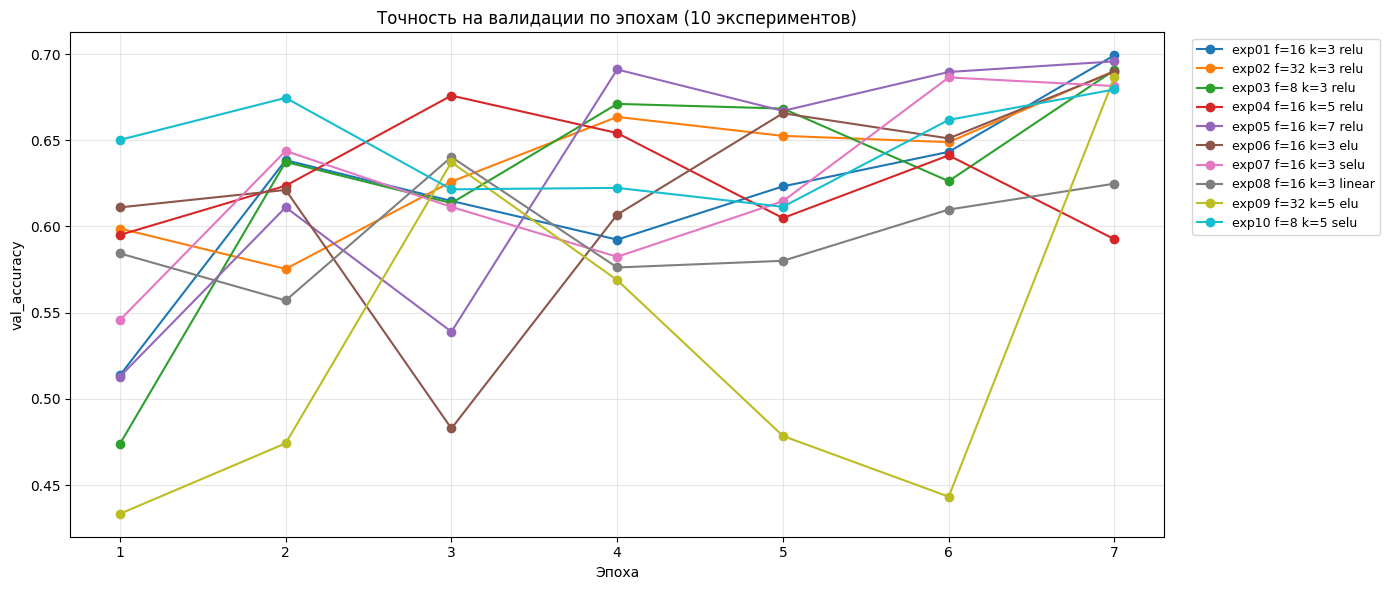

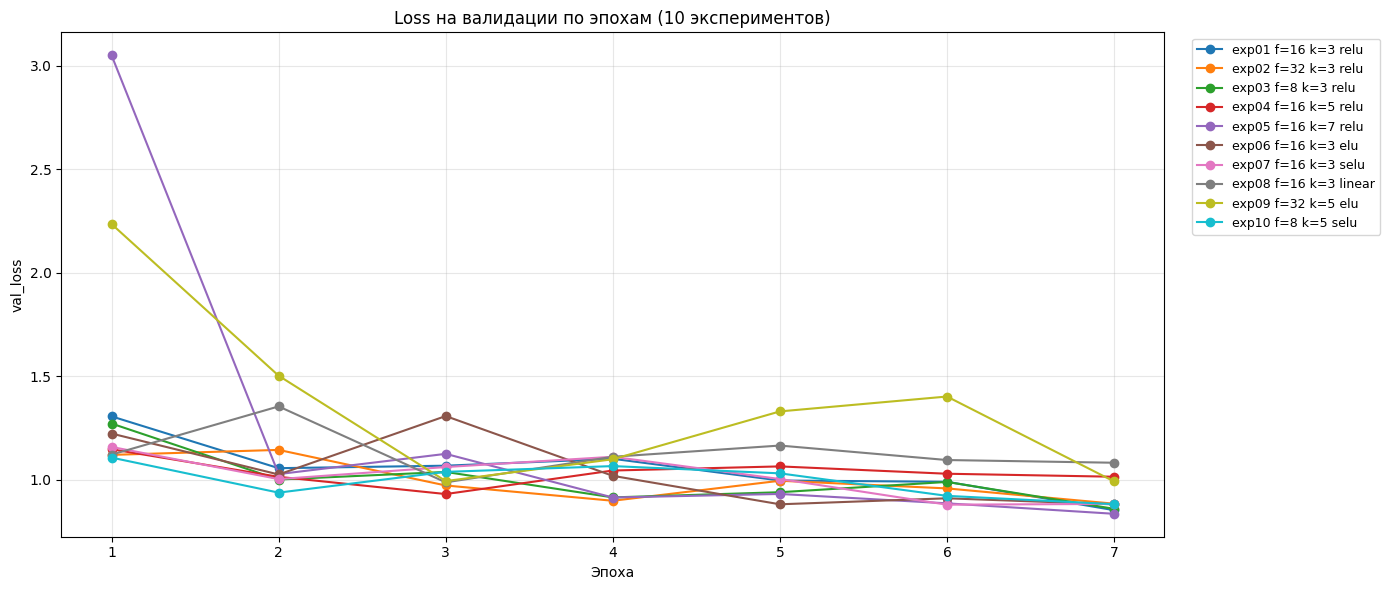

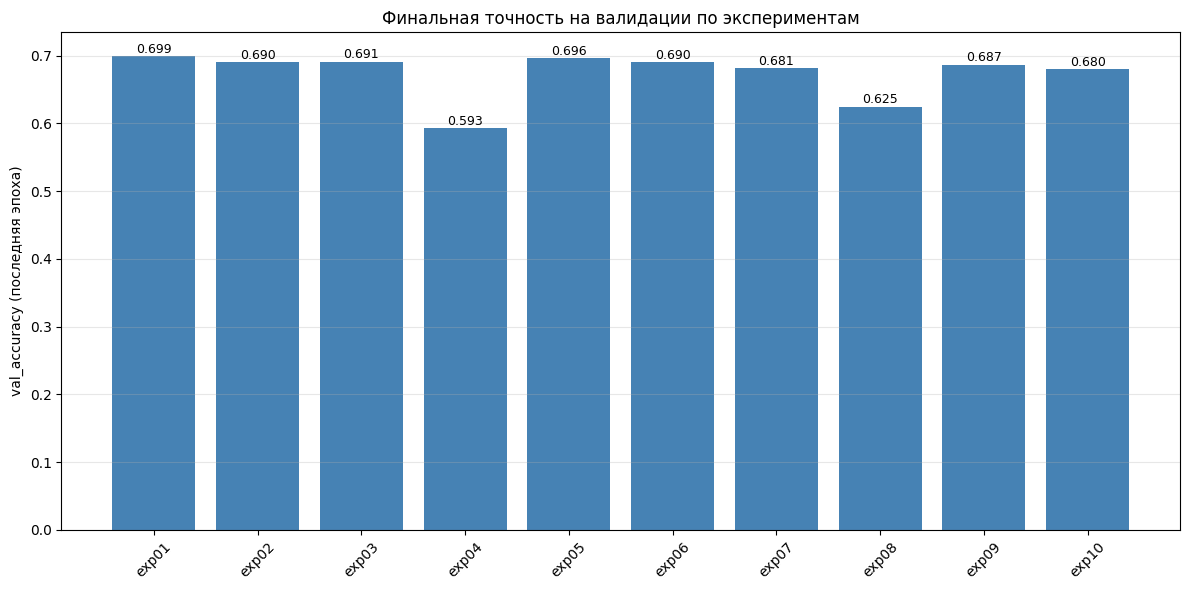


ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ
name    filters   kernel    activation    val_acc     val_loss    
--------------------------------------------------------------------------------
exp01   16        3         relu          0.6993      0.8532      
exp02   32        3         relu          0.6903      0.8844      
exp03   8         3         relu          0.6908      0.8599      
exp04   16        5         relu          0.5926      1.0148      
exp05   16        7         relu          0.6958      0.8357      
exp06   16        3         elu           0.6898      0.8813      
exp07   16        3         selu          0.6815      0.8835      
exp08   16        3         linear        0.6248      1.0824      
exp09   32        5         elu           0.6866      0.9921      
exp10   8         5         selu          0.6795      0.8822      

Лучший: exp01 — filters=16, kernel_size=3, activation=relu, val_acc=0.6993


In [ ]:
# 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

# (а) Кривые val_accuracy
plt.figure(figsize=(14, 6))
for r in results:
    label = f"{r['name']} f={r['filters']} k={r['kernel_size']} {r['activation']}"
    plt.plot(range(1, EPOCHS + 1), r['val_acc'], marker='o', label=label)
plt.title('Точность на валидации по эпохам (10 экспериментов)')
plt.xlabel('Эпоха'); plt.ylabel('val_accuracy')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

# (б) Кривые val_loss
plt.figure(figsize=(14, 6))
for r in results:
    label = f"{r['name']} f={r['filters']} k={r['kernel_size']} {r['activation']}"
    plt.plot(range(1, EPOCHS + 1), r['val_loss'], marker='o', label=label)
plt.title('Loss на валидации по эпохам (10 экспериментов)')
plt.xlabel('Эпоха'); plt.ylabel('val_loss')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

# (в) Финальная val_accuracy — столбчатая
plt.figure(figsize=(12, 6))
names  = [r['name'] for r in results]
finals = [r['final_val_acc'] for r in results]
bars = plt.bar(names, finals, color='steelblue')
plt.title('Финальная точность на валидации по экспериментам')
plt.ylabel('val_accuracy (последняя эпоха)')
plt.xticks(rotation=45)
for bar, v in zip(bars, finals):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.005,
             f'{v:.3f}', ha='center', fontsize=9)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# (г) Итоговая таблица
print('\n' + '=' * 80)
print('ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ')
print('=' * 80)
print(f"{'name':<8}{'filters':<10}{'kernel':<10}{'activation':<14}{'val_acc':<12}{'val_loss':<12}")
print('-' * 80)
for r in results:
    print(f"{r['name']:<8}{r['filters']:<10}{r['kernel_size']:<10}"
          f"{r['activation']:<14}{r['final_val_acc']:<12.4f}{r['final_val_loss']:<12.4f}")
print('=' * 80)

best = max(results, key=lambda r: r['final_val_acc'])
print(f"\nЛучший: {best['name']} — filters={best['filters']}, "
      f"kernel_size={best['kernel_size']}, activation={best['activation']}, "
      f"val_acc={best['final_val_acc']:.4f}")


Epoch 1/7
238/238 - 41s - 172ms/step - accuracy: 0.4356 - loss: 1.2616 - val_accuracy: 0.3729 - val_loss: 1.2821
Epoch 2/7
238/238 - 13s - 54ms/step - accuracy: 0.6848 - loss: 0.8573 - val_accuracy: 0.6002 - val_loss: 1.0168
Epoch 3/7
238/238 - 13s - 56ms/step - accuracy: 0.7303 - loss: 0.7553 - val_accuracy: 0.5937 - val_loss: 1.0197
Epoch 4/7
238/238 - 13s - 55ms/step - accuracy: 0.7465 - loss: 0.7100 - val_accuracy: 0.6538 - val_loss: 0.9545
Epoch 5/7
238/238 - 13s - 54ms/step - accuracy: 0.7645 - loss: 0.6702 - val_accuracy: 0.6585 - val_loss: 0.9139
Epoch 6/7
238/238 - 13s - 53ms/step - accuracy: 0.7731 - loss: 0.6472 - val_accuracy: 0.6745 - val_loss: 0.8818
Epoch 7/7
238/238 - 13s - 54ms/step - accuracy: 0.7840 - loss: 0.6219 - val_accuracy: 0.6780 - val_loss: 0.9020
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


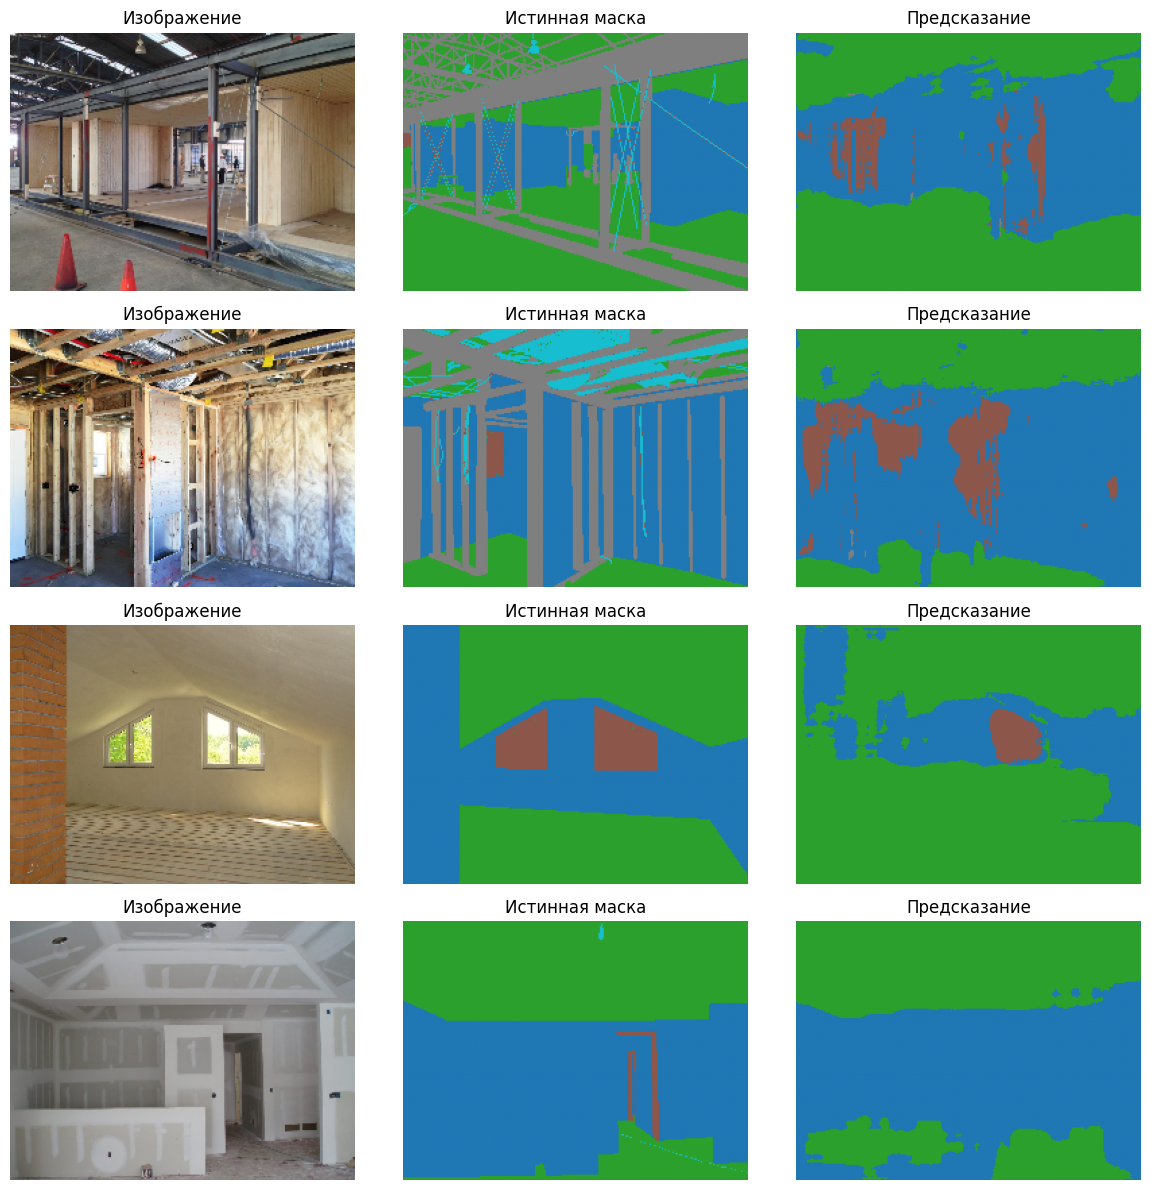

0

In [ ]:
# 5. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ ЛУЧШЕЙ МОДЕЛИ
import tensorflow as tf
tf.keras.backend.clear_session(); gc.collect()

best_model = build_unet(IMG_H, IMG_W,
                        filters=best['filters'],
                        kernel_size=best['kernel_size'],
                        activation=best['activation'])
best_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

# Несколько примеров с валидации
n_show = 4
idxs = np.random.choice(len(x_val), n_show, replace=False)
sample_x = x_val[idxs]                   # uint8, модель сама поделит на 255
preds = best_model.predict(sample_x, batch_size=BATCH_SIZE)
pred_classes = np.argmax(preds, axis=-1)
true_classes = y_val[idxs]

fig, axes = plt.subplots(n_show, 3, figsize=(12, 3 * n_show))
for i in range(n_show):
    axes[i, 0].imshow(sample_x[i]);       axes[i, 0].set_title('Изображение');  axes[i, 0].axis('off')
    axes[i, 1].imshow(true_classes[i], cmap='tab10', vmin=0, vmax=NUM_CLASSES-1); axes[i, 1].set_title('Истинная маска'); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred_classes[i], cmap='tab10', vmin=0, vmax=NUM_CLASSES-1); axes[i, 2].set_title('Предсказание');   axes[i, 2].axis('off')
plt.tight_layout(); plt.show()

del best_model, preds, sample_x
tf.keras.backend.clear_session(); gc.collect()
